## Install & Import

In [ ]:
!pip -q install datasets evaluate scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.3 MB/s eta 0:00:00


In [ ]:
import os
import re
import ast
import json
import math
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

dataset = load_dataset("jordiclive/FABSA")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/747k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/158k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7930 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1057 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1587 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 7930
    })
    validation: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 1057
    })
    test: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 1587
    })
})

##Convert from HuggingFace to Pandas Dataframe

The FABSA dataset loaded from Hugging Face and converted into Pandas DataFrames. The dataset was split for the training, validation, and test.

The dataset consists of 7930 training samples, 1057 validation samples, and 1587 test samples, each containing review text along with associated aspect sentiment annotations.

In [ ]:
def to_df(split):
    return pd.DataFrame(dataset[split])

train_df = to_df("train")
val_df = to_df("validation")
test_df = to_df("test")

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

(7930, 7) (1057, 7) (1587, 7)


,id,org_index,data_source,industry,text,labels,label_codes
0,301972057,600,Trustpilot,Price Comparison,My experience is only around the Parking forum...,"[[Staff support: Attitude of staff, negative],...","['staff-support.attitude-of-staff.-1', 'compan..."
1,301982453,514,Google Play,Banking,"I love it so handy, plus I hate my bank so it ...","[[Company brand: General satisfaction, positiv...","['company-brand.general-satisfaction.1', 'comp..."
2,301980653,369,Google Play,Ride Hailing,Sometimes it takes,"[[Company brand: General satisfaction, negative]]",['company-brand.general-satisfaction.-1']
3,301979991,727,Apple Store,Fashion,This is the worst app I ordered my sneakers 2/...,"[[Logistics rides: Speed, negative], [Online e...","['logistics-rides.speed.-1', 'online-experienc..."
4,301984330,549,Google Play,Travel Booking,So easy & loads of info !,"[[Company brand: General satisfaction, positive]]",['company-brand.general-satisfaction.1']


##Schema normalization + label space extraction

Normalising the labels and created a new column called "labels_parsed"

In [ ]:
def normalize_labels_cell(x):
    '''
    FABSA labels are typically stored like:
    [["Company brand: General satisfaction", "positive"], ...]
    This function converts the field safely to a Python list.
    '''
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

for df in [train_df, val_df, test_df]:
    df["labels_parsed"] = df["labels"].apply(normalize_labels_cell)

all_aspects = sorted({
    aspect for df in [train_df, val_df, test_df]
    for labels in df["labels_parsed"]
    for aspect, sent in labels
})

all_sentiments = sorted({
    sent for df in [train_df, val_df, test_df]
    for labels in df["labels_parsed"]
    for aspect, sent in labels
})

print("Number of aspects:", len(all_aspects))
print("Aspects:", all_aspects)
print("Sentiments:", all_sentiments)

Number of aspects: 12
Aspects: ['Account management: Account access', 'Company brand: Competitor', 'Company brand: General satisfaction', 'Company brand: Reviews', 'Logistics rides: Speed', 'Online experience: App website', 'Purchase booking experience: Ease of use', 'Staff support: Attitude of staff', 'Staff support: Email', 'Staff support: Phone', 'Value: Discounts promotions', 'Value: Price value for money']
Sentiments: ['negative', 'neutral', 'positive']


##Exploratory Data Analysis

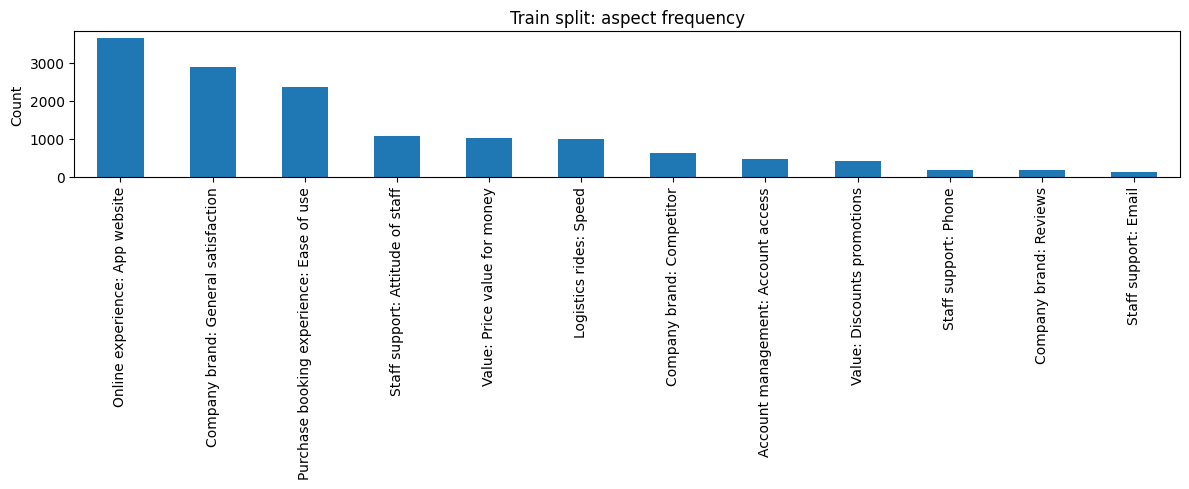

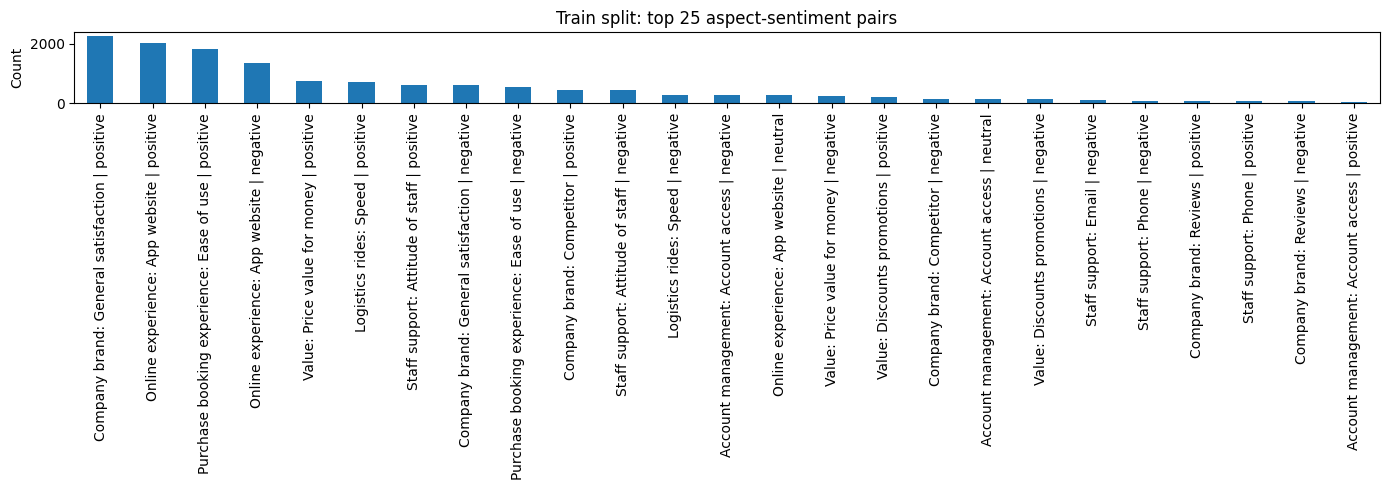

In [ ]:
aspect_counter = Counter()
pair_counter = Counter()

for labels in train_df["labels_parsed"]:
    for aspect, sent in labels:
        aspect_counter[aspect] += 1
        pair_counter[(aspect, sent)] += 1

aspect_series = pd.Series(aspect_counter).sort_values(ascending=False)
pair_series = pd.Series({f"{a} | {s}": c for (a, s), c in pair_counter.items()}).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
aspect_series.plot(kind="bar")
plt.title("Train split: aspect frequency")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
pair_series.head(25).plot(kind="bar")
plt.title("Train split: top 25 aspect-sentiment pairs")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

##Setup

In [ ]:
import tensorflow as tf
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, classification_report

tf.random.set_seed(SEED)

MAX_TOKENS = 30000
SEQ_LEN = 160
EMBED_DIM = 128
BATCH_SIZE = 64
EPOCHS = 8

##ACD Data Prep

dataset was prepared for Aspect Category Detection (ACD) by converting aspect labels into a multi-label binary format using MultiLabelBinarizer.

A TensorFlow TextVectorization layer is created and adapted to convert raw text into fixed-length numerical sequences for model input.

The data is organised into efficient TensorFlow datasets with batching, shuffling, and prefetching to optimise training performance.

In [ ]:
# ---------- ACD data ----------
def get_acd_targets(df):
    return [[aspect for aspect, sent in labels] for labels in df["labels_parsed"]]

mlb = MultiLabelBinarizer(classes=all_aspects)
Y_train_acd = mlb.fit_transform(get_acd_targets(train_df))
Y_val_acd = mlb.transform(get_acd_targets(val_df))
Y_test_acd = mlb.transform(get_acd_targets(test_df))

vectorizer_acd = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQ_LEN,
    standardize="lower_and_strip_punctuation"
)
vectorizer_acd.adapt(tf.data.Dataset.from_tensor_slices(train_df["text"].values).batch(256))

def make_text_ds(texts, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((texts.values, labels))
    if training:
        ds = ds.shuffle(len(texts), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_acd_ds = make_text_ds(train_df["text"], Y_train_acd, training=True)
val_acd_ds = make_text_ds(val_df["text"], Y_val_acd)
test_acd_ds = make_text_ds(test_df["text"], Y_test_acd)

##BiLSTM Model for Aspect Category Detection

Bidirectional LSTM-based neural network is emploted for multi-label aspect detection. The model outputs a probability for each aspect using a sigmoid activation, allowing multiple aspects to be predicted simultaneously.

It is checked with binary cross-entropy loss, which is appropriate for multi-label classification tasks.

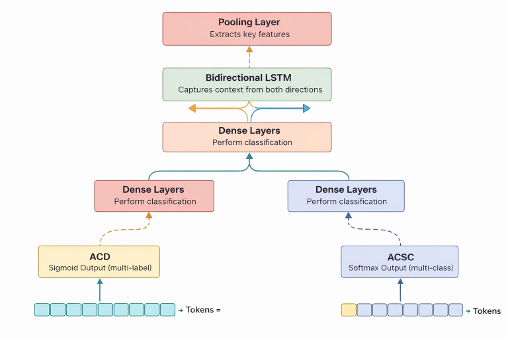

In [ ]:
def build_bilstm_multilabel(num_labels):
    inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
    x = vectorizer_acd(inputs)
    x = tf.keras.layers.Embedding(MAX_TOKENS, EMBED_DIM, mask_zero=True)(x)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(x)
    x = tf.keras.layers.GlobalMaxPooling1D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_labels, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy"
    )
    return model

acd_model = build_bilstm_multilabel(len(all_aspects))
acd_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 160)       │          0 │ input_layer[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 160, 128)  │  3,840,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 160)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 160, 128)  │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bidirectional[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 12)        │      1,548 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,956,876 (15.09 MB)

 Trainable params: 3,956,876 (15.09 MB)

 Non-trainable params: 0 (0.00 B)

##Training

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
]

history = acd_model.fit(
    train_acd_ds,
    validation_data=val_acd_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/8
124/124 ━━━━━━━━━━━━━━━━━━━━ 77s 575ms/step - loss: 0.4040 - val_loss: 0.3147
Epoch 2/8
124/124 ━━━━━━━━━━━━━━━━━━━━ 89s 635ms/step - loss: 0.2914 - val_loss: 0.2571
Epoch 3/8
124/124 ━━━━━━━━━━━━━━━━━━━━ 74s 601ms/step - loss: 0.2480 - val_loss: 0.2359
Epoch 4/8
124/124 ━━━━━━━━━━━━━━━━━━━━ 107s 800ms/step - loss: 0.2113 - val_loss: 0.2122
Epoch 5/8
124/124 ━━━━━━━━━━━━━━━━━━━━ 61s 490ms/step - loss: 0.1787 - val_loss: 0.1982
Epoch 6/8
124/124 ━━━━━━━━━━━━━━━━━━━━ 74s 599ms/step - loss: 0.1554 - val_loss: 0.1944
Epoch 7/8
124/124 ━━━━━━━━━━━━━━━━━━━━ 83s 672ms/step - loss: 0.1365 - val_loss: 0.1953
Epoch 8/8
124/124 ━━━━━━━━━━━━━━━━━━━━ 60s 482ms/step - loss: 0.1213 - val_loss: 0.1988


##Model Evaluation

Prediction probabilities are generated for the trained ACD model and performs threshold tuning on the validation set to optimise micro-F1 score.

In [ ]:
val_probs = acd_model.predict(val_acd_ds, verbose=0)
test_probs = acd_model.predict(test_acd_ds, verbose=0)

def threshold_search(y_true, probs, grid=np.arange(0.2, 0.81, 0.05)):
    best_t, best_f1 = 0.5, -1
    for t in grid:
        preds = (probs >= t).astype(int)
        score = f1_score(y_true, preds, average="micro", zero_division=0)
        if score > best_f1:
            best_t, best_f1 = t, score
    return best_t, best_f1

best_t, best_val_f1 = threshold_search(Y_val_acd, val_probs)
test_pred_acd = (test_probs >= best_t).astype(int)

print("Best validation threshold:", best_t)
print("Validation micro-F1:", best_val_f1)
print("Test micro-F1:", f1_score(Y_test_acd, test_pred_acd, average="micro", zero_division=0))
print("Test macro-F1:", f1_score(Y_test_acd, test_pred_acd, average="macro", zero_division=0))
print("Test subset accuracy:", accuracy_score(Y_test_acd, test_pred_acd))

Best validation threshold: 0.35
Validation micro-F1: 0.735793159170482
Test micro-F1: 0.7281449893390192
Test macro-F1: 0.47903941105200415
Test subset accuracy: 0.43163201008191554


##ACSC Data Prep

Turning each review into multiple rows, where each row represents one aspect and its sentiment.

In [ ]:
def build_pair_df(df):
    rows = []
    for _, row in df.iterrows():
        for aspect, sent in row["labels_parsed"]:
            rows.append({
                "text": row["text"],
                "aspect": aspect,
                "sentiment": sent,
                "pair_text": f"{row['text']} [ASPECT] {aspect}"
            })
    return pd.DataFrame(rows)

train_pair_df = build_pair_df(train_df)
val_pair_df = build_pair_df(val_df)
test_pair_df = build_pair_df(test_df)

label_encoder = LabelEncoder()
y_train_sent = label_encoder.fit_transform(train_pair_df["sentiment"])
y_val_sent = label_encoder.transform(val_pair_df["sentiment"])
y_test_sent = label_encoder.transform(test_pair_df["sentiment"])

vectorizer_acsc = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQ_LEN,
    standardize="lower_and_strip_punctuation"
)
vectorizer_acsc.adapt(tf.data.Dataset.from_tensor_slices(train_pair_df["pair_text"].values).batch(256))

def make_pair_ds(texts, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((texts.values, labels))
    if training:
        ds = ds.shuffle(len(texts), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_pair_ds = make_pair_ds(train_pair_df["pair_text"], y_train_sent, training=True)
val_pair_ds = make_pair_ds(val_pair_df["pair_text"], y_val_sent)
test_pair_ds = make_pair_ds(test_pair_df["pair_text"], y_test_sent)

##BiLSTM Model

Building a Bidirectional LSTM model to classify sentiment for each review aspect pair

In [ ]:
def build_bilstm_multiclass(num_labels):
    inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
    x = vectorizer_acsc(inputs)
    x = tf.keras.layers.Embedding(MAX_TOKENS, EMBED_DIM, mask_zero=True)(x)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(x)
    x = tf.keras.layers.GlobalMaxPooling1D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_labels, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

acsc_model = build_bilstm_multiclass(len(label_encoder.classes_))
acsc_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d_1' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 160)       │          0 │ input_layer_1[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 160, 128)  │  3,840,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 160)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 160, 128)  │     98,816 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bidirectional_1[… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │        387 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,955,715 (15.09 MB)

 Trainable params: 3,955,715 (15.09 MB)

 Non-trainable params: 0 (0.00 B)

##Training

In [ ]:
history2 = acsc_model.fit(
    train_pair_ds,
    validation_data=val_pair_ds,
    epochs=EPOCHS,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]
)

Epoch 1/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 116s 504ms/step - accuracy: 0.8338 - loss: 0.4196 - val_accuracy: 0.8924 - val_loss: 0.2861
Epoch 2/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 140s 495ms/step - accuracy: 0.9332 - loss: 0.2027 - val_accuracy: 0.8988 - val_loss: 0.2633
Epoch 3/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 142s 495ms/step - accuracy: 0.9499 - loss: 0.1502 - val_accuracy: 0.8977 - val_loss: 0.2667
Epoch 4/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 109s 500ms/step - accuracy: 0.9564 - loss: 0.1171 - val_accuracy: 0.8999 - val_loss: 0.2678


##Evaluation

In [ ]:
test_probs_sent = acsc_model.predict(test_pair_ds, verbose=0)
test_pred_sent = test_probs_sent.argmax(axis=1)

print("Test accuracy:", accuracy_score(y_test_sent, test_pred_sent))
print("Test micro-F1:", f1_score(y_test_sent, test_pred_sent, average="micro"))
print("Test macro-F1:", f1_score(y_test_sent, test_pred_sent, average="macro"))
print(classification_report(
    y_test_sent,
    test_pred_sent,
    target_names=label_encoder.classes_,
    digits=4
))

# End-to-end
def predict_aspects_for_texts(texts):
    probs = acd_model.predict(tf.data.Dataset.from_tensor_slices(texts).batch(BATCH_SIZE), verbose=0)
    preds = (probs >= best_t).astype(int)
    out = []
    for i, row in enumerate(preds):
        aspects = [mlb.classes_[j] for j, v in enumerate(row) if v == 1]
        if not aspects:
            aspects = [mlb.classes_[int(np.argmax(probs[i]))]]
        out.append(aspects)
    return out

def predict_sentiment(text, aspect):
    x = tf.constant([f"{text} [ASPECT] {aspect}"])
    probs = acsc_model.predict(x, verbose=0)
    return label_encoder.inverse_transform([int(np.argmax(probs))])[0]

gold_pairs, pred_pairs = [], []
predicted_aspects = predict_aspects_for_texts(test_df["text"].tolist())

for row, pred_aspects in zip(test_df.itertuples(index=False), predicted_aspects):
    gold = {(a, s) for a, s in row.labels_parsed}
    pred = {(a, predict_sentiment(row.text, a)) for a in pred_aspects}
    gold_pairs.append(gold)
    pred_pairs.append(pred)

def multilabel_pair_f1(gold_sets, pred_sets):
    tp = fp = fn = 0
    for gold, pred in zip(gold_sets, pred_sets):
        tp += len(gold & pred)
        fp += len(pred - gold)
        fn += len(gold - pred)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return {"precision": precision, "recall": recall, "f1": f1}

multilabel_pair_f1(gold_pairs, pred_pairs)

Test accuracy: 0.90149359886202
Test micro-F1: 0.90149359886202
Test macro-F1: 0.8439196473929597
              precision    recall  f1-score   support

    negative     0.8579    0.8493    0.8536       896
     neutral     0.8806    0.6484    0.7468        91
    positive     0.9230    0.9397    0.9313      1825

    accuracy                         0.9015      2812
   macro avg     0.8872    0.8125    0.8439      2812
weighted avg     0.9009    0.9015    0.9006      2812



/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d_1' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


{'precision': 0.6644436644434313,
 'recall': 0.6731863442387365,
 'f1': 0.6687864329921009}